In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Navigate to Phase 2
%cd /content/drive/MyDrive/AIKONIC-AI/PHASE_02

import sys, os
import matplotlib.pyplot as plt
import tensorflow as tf

# Project root resolution
PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import config
from model import build_model, partial_unfreeze, save_architecture_summary
from data_loader import DataLoader
from callbacks import get_phase_a_callbacks, get_phase_b_callbacks

# Create output directories in Mother Drive
for d in [config.CHECKPOINTS_DIR, config.LOGS_DIR, config.REPORTS_DIR,
          config.EVAL_DIR, config.TRAINING_PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Load Data
loader = DataLoader()
class_weights = loader.get_class_weights()
train_ds = loader.get_train_dataset()
val_ds = loader.get_val_dataset()

print("Environment and Data Loader ready.")

Mounted at /content/drive
/content/drive/MyDrive/AIKONIC-AI/PHASE_02
[DataLoader] Class weights: {0: 1.0, 1: 1.0}
Environment and Data Loader ready.


In [ ]:
# Build & Train Phase A (Frozen Base)
print("Building DysgraphiaCNN (Phase A)...")
model = build_model(freeze_base=True, learning_rate=config.PHASE_A_LR)

history_a = model.fit(
    train_ds, validation_data=val_ds, epochs=config.PHASE_A_EPOCHS,
    callbacks=get_phase_a_callbacks(), class_weight=class_weights, verbose=1
)
print(f"Phase A complete → {config.CHECKPOINT_PHASE_A_KERAS}")

# Build & Train Phase B (Partial Unfreeze)
print("\nInitiating Phase B (Partial Unfreeze)...")
model = partial_unfreeze(model, unfreeze_fraction=config.PHASE_B_UNFREEZE_FRACTION)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config.PHASE_B_LR),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

history_b = model.fit(
    train_ds, validation_data=val_ds, epochs=config.PHASE_B_EPOCHS,
    callbacks=get_phase_b_callbacks(), class_weight=class_weights, verbose=1
)

# Save Legacy H5 for submission
model.save(config.CHECKPOINT_PROD)
print(f"Phase B complete → {config.CHECKPOINT_PROD_KERAS}")

Building DysgraphiaCNN (Phase A)...
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
618/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6739 - auc: 0.7309 - loss: 0.6023 - precision: 0.6739 - recall: 0.6739
Epoch 1: val_loss improved from None to 0.58150, saving model to /content/drive/MyDrive/AIKONIC-AI/checkpoints/phase_a_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIKONIC-AI/checkpoints/phase_a_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 1560s 67ms/step - accuracy: 0.7207 - auc: 0.7901 - loss: 0.5555 - precision: 0.7207 - recall: 0.7207 - val_accuracy: 0.7278 - val_auc: 0.7767 - val_loss: 0.5815 - val_precision: 0.7278 - val_recall: 0.7278 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7751 - auc: 0.8454 - loss: 0.4907 - precision: 0.7751 - recall: 0.7751
Epoch 2: val_loss improved from 0.58150 to 0.57307, saving model to /content/drive/MyDrive/AIKONIC-AI/checkpoints/phase_a_best.keras

Epoch 2: finis

Phase B complete → /content/drive/MyDrive/AIKONIC-AI/checkpoints/production_model.keras


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

print("Evaluating metrics safely (Single-Pass)...")

# Helper function for safe extraction
def get_metrics_single_pass(dataset):
    y_true_list = []
    y_pred_list = []

    # Iterate exactly once so shuffling doesn't break alignment
    for images, labels in dataset:
        # Use model() instead of predict() for batch-level speed
        preds = model(images, training=False)
        y_pred_list.append(np.argmax(preds.numpy(), axis=1))
        y_true_list.append(np.argmax(labels.numpy(), axis=1))

    y_true = np.concatenate(y_true_list, axis=0)
    y_pred = np.concatenate(y_pred_list, axis=0)

    return y_true, y_pred

# 1. Evaluate Training Set
print("Processing Training Set...")
train_dict = model.evaluate(train_ds, verbose=0, return_dict=True)
train_acc = get_metric(train_dict, 'acc')
train_auc = get_metric(train_dict, 'auc')

train_true, train_pred = get_metrics_single_pass(train_ds)
train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(
    train_true, train_pred, average='macro', zero_division=0
)

# 2. Evaluate Validation Set
print("Processing Validation Set...")
val_dict = model.evaluate(val_ds, verbose=0, return_dict=True)
val_acc = get_metric(val_dict, 'acc')
val_auc = get_metric(val_dict, 'auc')

val_true, val_pred = get_metrics_single_pass(val_ds)
val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
    val_true, val_pred, average='macro', zero_division=0
)

# 3. Print Simple Comparison Table
print("\n" + "="*40)
print(" FINAL METRIC COMPARISON")
print("="*40)
print(f"  {'METRIC':<12} | {'TRAIN':<8} | {'VAL'}")
print("-" * 40)
print(f"  {'ACCURACY':<12} | {train_acc:<8.4f} | {val_acc:.4f}")
print(f"  {'PRECISION':<12} | {train_prec:<8.4f} | {val_prec:.4f}")
print(f"  {'RECALL':<12} | {train_rec:<8.4f} | {val_rec:.4f}")
print(f"  {'F1 SCORE':<12} | {train_f1:<8.4f} | {val_f1:.4f}")
print(f"  {'AUROC':<12} | {train_auc:<8.4f} | {val_auc:.4f}")
print("="*40)

Evaluating metrics safely (Single-Pass)...
Processing Training Set...
Processing Validation Set...

 FINAL METRIC COMPARISON
  METRIC       | TRAIN    | VAL
----------------------------------------
  ACCURACY     | 0.8059   | 0.7025
  PRECISION    | 0.8138   | 0.7020
  RECALL       | 0.8059   | 0.6923
  F1 SCORE     | 0.8047   | 0.6936
  AUROC        | 0.8803   | 0.7377


✓ Saved learning curves to /content/drive/MyDrive/AIKONIC-AI/training_plots/final_learning_curves.png


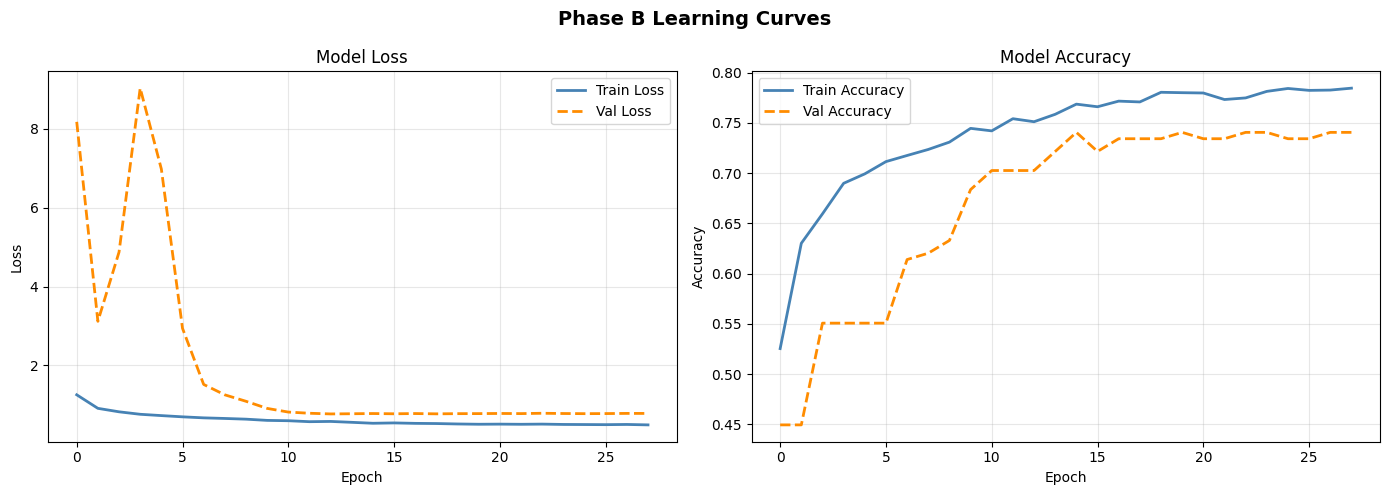

In [ ]:
# Visual Learning Curves
import matplotlib.pyplot as plt
import os

# Create a figure with two subplots (Loss and Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase B Learning Curves", fontsize=14, fontweight="bold")

# Plot Loss
axes[0].plot(history_b.history['loss'], label='Train Loss', lw=2, color='steelblue')
axes[0].plot(history_b.history['val_loss'], label='Val Loss', lw=2, linestyle='--', color='darkorange')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot Accuracy
axes[1].plot(history_b.history['accuracy'], label='Train Accuracy', lw=2, color='steelblue')
axes[1].plot(history_b.history['val_accuracy'], label='Val Accuracy', lw=2, linestyle='--', color='darkorange')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Save it to your Mother Drive
plot_path = os.path.join(config.TRAINING_PLOTS_DIR, "final_learning_curves.png")
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
print(f"✓ Saved learning curves to {plot_path}")

plt.show()